# Assignment 2 – Task 1: Titanic Passenger Survival Prediction System
---
**Deployment Link:** [https://ml-teaching-notebooks-jrrdwercxskw5kwc6rufvp.streamlit.app/](https://ml-teaching-notebooks-jrrdwercxskw5kwc6rufvp.streamlit.app/)

This notebook follows the complete Machine Learning lifecycle:
1. Data Collection
2. Data Understanding (EDA)
3. Data Pre-processing & Label Encoding
4. Model Training (SVC)
5. Model Evaluation
6. Making Predictions
7. Saving the Trained Model

**Dataset:** Titanic (built-in seaborn dataset)  
**Algorithm:** Support Vector Classifier (SVC)


## Step 0 – Import Libraries

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
warnings.filterwarnings("ignore")
print("Libraries imported successfully OK")

Libraries imported successfully OK


## Step 1 – Data Collection
Load the Titanic dataset (seaborn built-in).

In [2]:
df = sns.load_dataset("titanic")
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Step 2 – Data Understanding (EDA)

In [3]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [4]:
print("=== Descriptive Statistics ===")
df.describe()

=== Descriptive Statistics ===


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("=== Missing Values ===")
df.isnull().sum()

=== Missing Values ===


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

=== Survival Distribution ===
survived
0    549
1    342
Name: count, dtype: int64


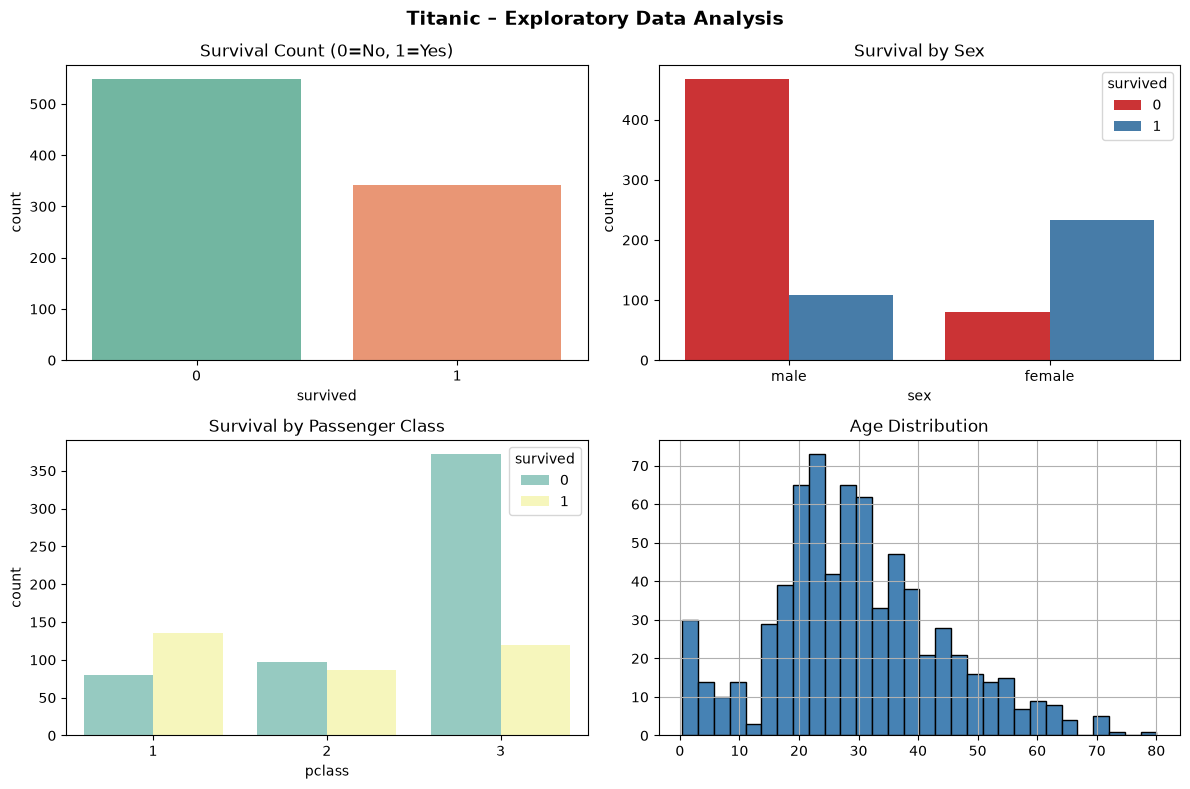

EDA plots saved OK


In [6]:
print("=== Survival Distribution ===")
print(df["survived"].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Titanic – Exploratory Data Analysis", fontsize=14, fontweight="bold")

sns.countplot(data=df, x="survived", ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Survival Count (0=No, 1=Yes)")

sns.countplot(data=df, x="sex", hue="survived", ax=axes[0,1], palette="Set1")
axes[0,1].set_title("Survival by Sex")

sns.countplot(data=df, x="pclass", hue="survived", ax=axes[1,0], palette="Set3")
axes[1,0].set_title("Survival by Passenger Class")

df["age"].dropna().hist(bins=30, ax=axes[1,1], color="steelblue", edgecolor="black")
axes[1,1].set_title("Age Distribution")

plt.tight_layout()
plt.savefig("titanic_eda.png", dpi=100)
plt.show()
print("EDA plots saved OK")

## Step 3 – Data Pre-processing & Label Encoding

In [7]:
# Select relevant features
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target   = "survived"

df_model = df[features + [target]].copy()
df_model.dropna(inplace=True)
print(f"Shape after dropping nulls: {df_model.shape}")

# Label Encoding
le_sex      = LabelEncoder()
le_embarked = LabelEncoder()

df_model["sex"]      = le_sex.fit_transform(df_model["sex"])
df_model["embarked"] = le_embarked.fit_transform(df_model["embarked"])

# Save encoded dataset
df_model.to_csv("titanic_encoded.csv", index=False)
print("Encoded dataset saved to titanic_encoded.csv OK")
df_model.head()

Shape after dropping nulls: (712, 8)


Encoded dataset saved to titanic_encoded.csv OK


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


## Step 4 – Model Training (Support Vector Classifier)

In [8]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

svc = SVC(kernel="rbf", random_state=42)
svc.fit(X_train, y_train)
print("\nSVC model trained successfully OK")

Training samples : 569
Testing  samples : 143

SVC model trained successfully OK


## Step 5 – Model Evaluation

Accuracy: 63.64%

Confusion Matrix:
[[67 13]
 [39 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.84      0.72        80
           1       0.65      0.38      0.48        63

    accuracy                           0.64       143
   macro avg       0.64      0.61      0.60       143
weighted avg       0.64      0.64      0.61       143



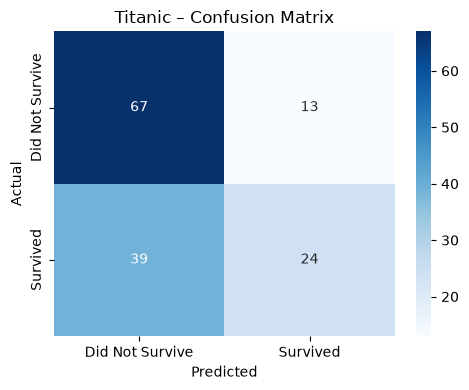

In [9]:
y_pred = svc.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
cm     = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did Not Survive","Survived"],
            yticklabels=["Did Not Survive","Survived"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Titanic – Confusion Matrix")
plt.tight_layout()
plt.savefig("titanic_confusion_matrix.png", dpi=100)
plt.show()

## Step 6 – Making Predictions on Sample Data

In [10]:
sample_raw = pd.DataFrame({
    "pclass":   [1,    3,    2],
    "sex":      ["female", "male", "female"],
    "age":      [29,   22,   35],
    "sibsp":    [0,    1,    1],
    "parch":    [0,    0,    0],
    "fare":     [211,  7.25, 26],
    "embarked": ["S",  "S",  "C"],
})
sample = sample_raw.copy()
sample["sex"]      = le_sex.transform(sample["sex"])
sample["embarked"] = le_embarked.transform(sample["embarked"])

predictions = svc.predict(sample)
sample_raw["Predicted_Survival"] = ["Survived ✓" if p==1 else "Did Not Survive ✗"
                                     for p in predictions]

# Save predictions
sample_raw.to_csv("titanic_predictions.csv", index=False)
print("Predictions saved to titanic_predictions.csv OK")
sample_raw

Predictions saved to titanic_predictions.csv OK


,pclass,sex,age,sibsp,parch,fare,embarked,Predicted_Survival
0,1,female,29,0,0,211.00,S,Survived ✓
1,3,male,22,1,0,7.25,S,Did Not Survive ✗
2,2,female,35,1,0,26.00,C,Did Not Survive ✗


## Step 7 – Save Trained Model

In [11]:
with open("titanic_svc_model.pkl", "wb") as f:
    pickle.dump(svc, f)

print("Model saved to titanic_svc_model.pkl OK")
print("\n" + "="*50)
print("TASK 1 COMPLETE")
print("="*50)

Model saved to titanic_svc_model.pkl OK

TASK 1 COMPLETE
